In [1]:
import pandas as pd


# Load file
df = pd.read_csv("data/raw/ai4i2020.csv")

# Clean column Names
#df.columns = [c.stripe() for c in df.columns]
#df.rename[["Product ID"]] = pd.df[["Product_ID"]]
df.rename(columns={"Product ID": "Product_ID",
                  "Air temperature [K]" : "Air_temperature",
                   "Process temperature [K]" : "Process_temperature",
                    "Rotational speed [rpm]" : "Rotational_speed" ,
                    "Torque [Nm]" : "Torque",
                    "Tool wear [min]" : "Toolwear",
                    "Machine failure": "Machine_failure"} , inplace=True)

# show first few rows
print(df.head())


   UDI Product_ID Type  Air_temperature  Process_temperature  \
0    1     M14860    M            298.1                308.6   
1    2     L47181    L            298.2                308.7   
2    3     L47182    L            298.1                308.5   
3    4     L47183    L            298.2                308.6   
4    5     L47184    L            298.2                308.7   

   Rotational_speed  Torque  Toolwear  Machine_failure  TWF  HDF  PWF  OSF  \
0              1551    42.8         0                0    0    0    0    0   
1              1408    46.3         3                0    0    0    0    0   
2              1498    49.4         5                0    0    0    0    0   
3              1433    39.5         7                0    0    0    0    0   
4              1408    40.0         9                0    0    0    0    0   

   RNF  
0    0  
1    0  
2    0  
3    0  
4    0  


In [2]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#fit + Transform
df["Type_encoded"] = le.fit_transform(df["Type"])
# df["Type_encoded"] = df["Type"].map({"L": 1, "M": 2, "H": 3}) - If want to have manually
df.head()

,UDI,Product_ID,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Toolwear,Machine_failure,TWF,HDF,PWF,OSF,RNF,Type_encoded
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,2
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1


In [3]:
# Minimal feature engineering (no scaling, no encoding)
import numpy as np

# 1) Delta temperature: Process - Air
df["Delta_temperature"] = df["Process_temperature"] - df["Air_temperature"]

# 2) Angular speed (rad/s) from rpm
df["Omega"] = df["Rotational_speed"] * (2 * np.pi / 60.0)

# 3) Calculated power (W) = torque * omega
df["Calc_power"] = df["Torque"] * df["Omega"]

# 4) Calculating power without calculating omega.
df["Power"] = df["Torque"] * df["Rotational_speed"]



Correct Formula for Angular Velocity (ω)
ω (rad/s) = rpm × (2π / 60)
Why?

1 full rotation = 2π radians

rpm = rotations per minute

To convert to per second, divide by 60

In [4]:
# Quick Verify
df[["Air_temperature", "Process_temperature", "Delta_temperature",  "Rotational_speed", "Omega", "Torque", "Calc_power", "Power" ]].head()

,Air_temperature,Process_temperature,Delta_temperature,Rotational_speed,Omega,Torque,Calc_power,Power
0,298.1,308.6,10.5,1551,162.420340,42.8,6951.590560,66382.8
1,298.2,308.7,10.5,1408,147.445415,46.3,6826.722724,65190.4
2,298.1,308.5,10.4,1498,156.870193,49.4,7749.387543,74001.2
3,298.2,308.6,10.4,1433,150.063409,39.5,5927.504659,56603.5
4,298.2,308.7,10.5,1408,147.445415,40.0,5897.816608,56320.0


##### Select features for Machine Failure & split into train/test

In [5]:
df_copy = df.copy()

In [6]:
from sklearn.model_selection import train_test_split
# Features we will use for TWF model
feature_cols = [
    "Type",
    "Air_temperature",
    "Process_temperature",
    "Delta_temperature",
    "Rotational_speed",
    #"Omega",
    "Torque",
    #"Calc_power",
    "Toolwear",
    "Power"
]

# X = inputs, y = target for TWF only
X = df[feature_cols]
y = df["Machine_failure"]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # stratify=y  It ensures the percentage of Machine_failure = 1 and Machine_failure = 0 is the same in both train and test sets.
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("positive in train:", y_train.sum())
print("positive in test :", y_test.sum())

Train shape: (7000, 8)
Test shape : (3000, 8)
positive in train: 237
positive in test : 102


In [7]:
numeric_columns = [
    "Air_temperature",
    "Process_temperature",
    "Delta_temperature",
    "Rotational_speed",
    #"Omega",
    "Torque",
    #"Calc_power",
    "Toolwear",
    "Power"
]

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), ["Type"]),
     ("num", "passthrough", numeric_columns)]
)

In [9]:
preprocessor.fit(X_train)

all_features = preprocessor.get_feature_names_out()
print(all_features)

['cat__Type_H' 'cat__Type_L' 'cat__Type_M' 'num__Air_temperature'
 'num__Process_temperature' 'num__Delta_temperature'
 'num__Rotational_speed' 'num__Torque' 'num__Toolwear' 'num__Power']


#### Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline_cmn = Pipeline(steps=[
   ("preprocess", preprocessor),
    ("random_forest", RandomForestClassifier(
        random_state=42,
        #n_jobs=-1
        n_estimators=400,
        #random_state=42,
        #class_weight= "balanced",
        n_jobs=-1
    ))
])

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_pipeline_cmn.fit(X_train, y_train)

# Predict
y_pred_brf = rf_pipeline_cmn.predict(X_test)


In [12]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_brf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_brf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_brf))

Accuracy: 0.991

Confusion Matrix:
[[2894    4]
 [  23   79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2898
           1       0.95      0.77      0.85       102

    accuracy                           0.99      3000
   macro avg       0.97      0.89      0.92      3000
weighted avg       0.99      0.99      0.99      3000



#### Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
   ("preprocess", preprocessor),
    ("random_forest", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [14]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

param_dist = {
    "random_forest__class_weight": [ {0:1,1:5}, {0:1,1:10}, {0:1,1:20}, "balanced_subsample" ], # for Class 0 give importance 1 and for class1(Failures) importance 5
    "random_forest__min_samples_leaf": [1, 2, 5, 10],
    "random_forest__min_samples_split": [2, 5, 10, 20],
    "random_forest__max_depth": [None, 8, 12, 16],
    "random_forest__max_features": ["sqrt", "log2", 0.5, 0.7, 0.9],
    "random_forest__n_estimators": [400, 700, 1000],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    rf_pipeline, param_distributions=param_dist, n_iter=40,
    scoring="f1", cv=cv, n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)
best = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [15]:
print(best)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type']),
                                                 ('num', 'passthrough',
                                                  ['Air_temperature',
                                                   'Process_temperature',
                                                   'Delta_temperature',
                                                   'Rotational_speed', 'Torque',
                                                   'Toolwear', 'Power'])])),
                ('random_forest',
                 RandomForestClassifier(class_weight={0: 1, 1: 5}, max_depth=16,
                                        max_features=0.9, min_samples_split=5,
                                        n_estimators=400, n_jobs=-1,
                                        random_state

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_best = best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=3))

Test Accuracy: 0.9916666666666667

Confusion Matrix:
[[2894    4]
 [  21   81]]

Classification Report:
              precision    recall  f1-score   support

           0      0.993     0.999     0.996      2898
           1      0.953     0.794     0.866       102

    accuracy                          0.992      3000
   macro avg      0.973     0.896     0.931      3000
weighted avg      0.991     0.992     0.991      3000



In [17]:
import shap
import numpy as np
import pandas as pd
from sklearn.utils.validation import check_is_fitted

d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
# 1) fitted pipeline from RandomizedSearchCV
fitted_pipe = best

In [19]:
# 2) split pipeline
preprocess = fitted_pipe.named_steps["preprocess"]
rf_model   = fitted_pipe.named_steps["random_forest"]

# ensure RandomForest is fitted
check_is_fitted(rf_model, "estimators_")

check_is_fitted(rf_model, "estimators_")

What: Confirms your RandomForest (rf_model) is already fitted.

Why: A fitted RandomForest has an attribute estimators_ (the trees). If it’s missing, SHAP can’t work and we stop early with a clear error.

In [20]:
# 3) transform X_test
Xte_trans = preprocess.transform(X_test)

# feature names
try:
    feat_names = preprocess.get_feature_names_out()
except:
    feat_names = [f"f_{i}" for i in range(Xte_trans.shape[1])]

# convert to dense DataFrame
if hasattr(Xte_trans, "toarray"):
    Xte_trans = Xte_trans.toarray()
Xte_trans = pd.DataFrame(Xte_trans, columns=feat_names, index=X_test.index)

In [46]:
Xte_trans


,cat__Type_H,cat__Type_L,cat__Type_M,num__Air_temperature,num__Process_temperature,num__Delta_temperature,num__Rotational_speed,num__Torque,num__Toolwear,num__Power
7809,0.0,0.0,1.0,300.0,311.4,11.4,1537.0,35.4,120.0,54409.8
9069,0.0,0.0,1.0,297.2,308.2,11.0,1678.0,28.1,133.0,47151.8
3170,0.0,0.0,1.0,300.4,309.7,9.3,1685.0,32.3,167.0,54425.5
2750,1.0,0.0,0.0,299.7,309.2,9.5,1456.0,40.6,182.0,59113.6
6986,0.0,1.0,0.0,300.7,311.1,10.4,1688.0,30.7,161.0,51821.6
...,...,...,...,...,...,...,...,...,...,...
5270,0.0,1.0,0.0,303.5,312.9,9.4,1275.0,64.4,113.0,82110.0
4610,0.0,1.0,0.0,303.1,311.2,8.1,1394.0,45.3,144.0,63148.2
6434,0.0,0.0,1.0,300.3,309.9,9.6,1494.0,38.5,33.0,57519.0
8351,0.0,0.0,1.0,298.7,309.6,10.9,1686.0,26.2,189.0,44173.2


In [47]:
list(Xte_trans.columns)

['cat__Type_H',
 'cat__Type_L',
 'cat__Type_M',
 'num__Air_temperature',
 'num__Process_temperature',
 'num__Delta_temperature',
 'num__Rotational_speed',
 'num__Torque',
 'num__Toolwear',
 'num__Power']

In [21]:
# 4) SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(Xte_trans)

In [22]:
shap_values

.values =
array([[[ 0.00028141, -0.00028141],
        [ 0.00378358, -0.00378358],
        [ 0.00212628, -0.00212628],
        ...,
        [ 0.02332397, -0.02332397],
        [ 0.02842872, -0.02842872],
        [ 0.03619114, -0.03619114]],

       [[ 0.00022813, -0.00022813],
        [ 0.00379096, -0.00379096],
        [ 0.00215744, -0.00215744],
        ...,
        [ 0.02517996, -0.02517996],
        [ 0.02747719, -0.02747719],
        [ 0.0352787 , -0.0352787 ]],

       [[ 0.00025322, -0.00025322],
        [ 0.00380436, -0.00380436],
        [ 0.0021771 , -0.0021771 ],
        ...,
        [ 0.02229958, -0.02229958],
        [ 0.02789387, -0.02789387],
        [ 0.04000681, -0.04000681]],

       ...,

       [[ 0.000295  , -0.000295  ],
        [ 0.00396337, -0.00396337],
        [ 0.00240006, -0.00240006],
        ...,
        [ 0.02360606, -0.02360606],
        [ 0.02716466, -0.02716466],
        [ 0.03693543, -0.03693543]],

       [[ 0.00021618, -0.00021618],
        [ 0.00719

In [23]:
# ----- FIX for classification -----
# take class 1 SHAP values: shape -> (n_samples, n_features)
sv_class1 = shap_values.values[:, :, 1]

In [24]:
sv_class1

array([[-0.00028141, -0.00378358, -0.00212628, ..., -0.02332397,
        -0.02842872, -0.03619114],
       [-0.00022813, -0.00379096, -0.00215744, ..., -0.02517996,
        -0.02747719, -0.0352787 ],
       [-0.00025322, -0.00380436, -0.0021771 , ..., -0.02229958,
        -0.02789387, -0.04000681],
       ...,
       [-0.000295  , -0.00396337, -0.00240006, ..., -0.02360606,
        -0.02716466, -0.03693543],
       [-0.00021618, -0.00719343, -0.00264395, ..., -0.0353073 ,
        -0.00982734, -0.03821621],
       [-0.00027394, -0.00381971, -0.00223167, ..., -0.02254323,
        -0.02675649, -0.03853946]], shape=(3000, 10))

In [25]:
# 5) SHAP table
mean_abs = np.abs(sv_class1).mean(axis=0)

In [26]:
shap_table_transformed = (
    pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

shap_table_transformed.head(10)

,feature,mean_abs_shap
0,num__Rotational_speed,0.048905
1,num__Toolwear,0.047584
2,num__Power,0.044472
3,num__Delta_temperature,0.040625
4,num__Torque,0.034956
5,num__Process_temperature,0.004275
6,num__Air_temperature,0.004141
7,cat__Type_L,0.003514
8,cat__Type_M,0.001593
9,cat__Type_H,0.000599


In [27]:
def to_original_feature(name):
    # remove num__ and cat__ prefixes
    name = name.split("__")[-1]

    # if it is one-hot encoded Type (Type_L, Type_M, Type_H)
    if name.startswith("Type_"):
        return "Type"

    return name

# Map each transformed feature -> original feature
shap_table_transformed["orig_feature"] = shap_table_transformed["feature"].apply(to_original_feature)

# Group and sum SHAPs for one-hot columns
shap_table_original = (
    shap_table_transformed.groupby("orig_feature", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
)

shap_table_original


,orig_feature,mean_abs_shap
4,Rotational_speed,0.048905
5,Toolwear,0.047584
2,Power,0.044472
1,Delta_temperature,0.040625
6,Torque,0.034956
7,Type,0.005706
3,Process_temperature,0.004275
0,Air_temperature,0.004141


In [41]:
clean_features = shap_table_transformed["orig_feature"][
    shap_table_transformed["orig_feature"] != "Type"
].unique()

clean_features

clean_df = pd.DataFrame({"feature": clean_features})
clean_df

features = clean_features.tolist()
features


['Rotational_speed',
 'Toolwear',
 'Power',
 'Delta_temperature',
 'Torque',
 'Process_temperature',
 'Air_temperature']

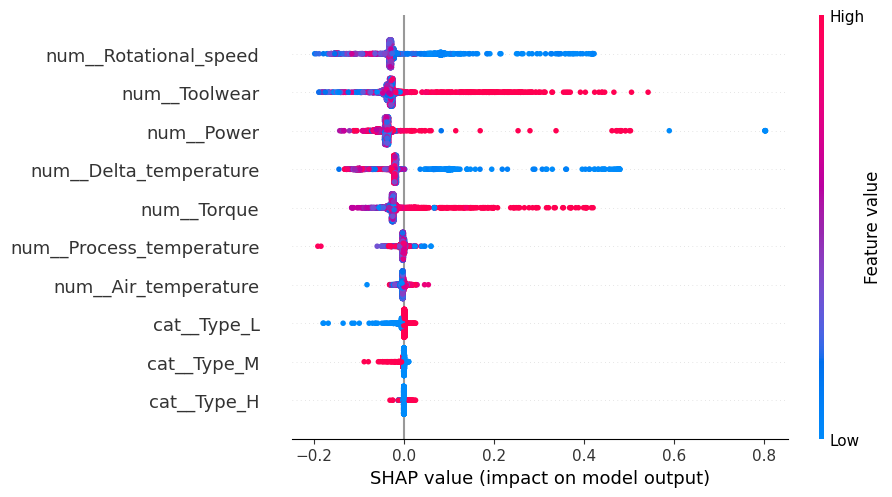

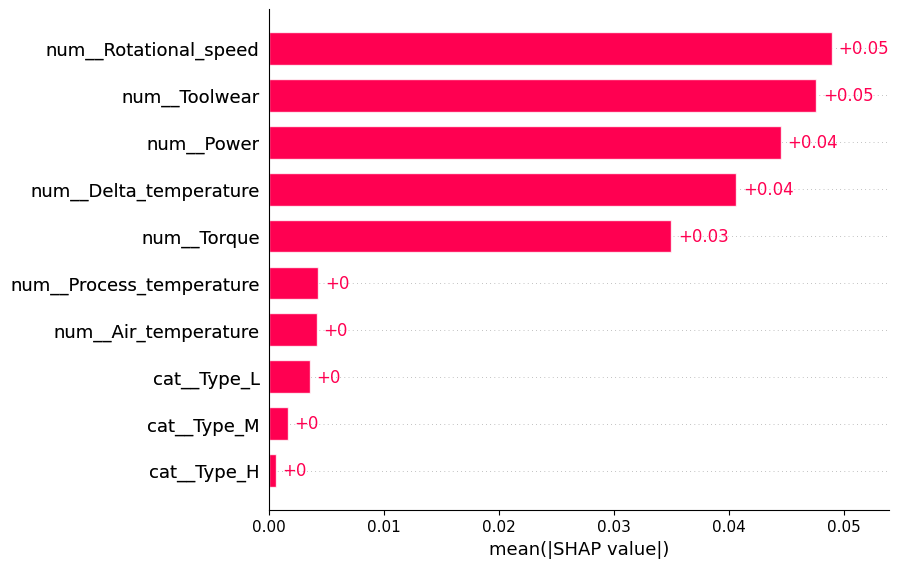

In [28]:
# choose class 1 (Failure) before plotting
shap.plots.beeswarm(shap_values[..., 1])   # beeswarm
shap.plots.bar(shap_values[..., 1])        # bar plot



In [58]:
mean_shap = sv_class1.mean(axis=0)

In [59]:
mean_shap

array([-0.00029381, -0.00254869, -0.00096535, -0.00285145, -0.00329061,
       -0.01576319, -0.01826343, -0.01498054, -0.01765112, -0.03552371])

In [65]:
mean_shap = sv_class1.mean(axis=0)
df_mean_shap = pd.DataFrame({"feature": feat_names, "mean_shap": mean_shap}) \
            .sort_values("mean_shap", ascending=False)


In [66]:
df_mean_shap.head(10)

,feature,mean_shap
0,cat__Type_H,-0.000294
2,cat__Type_M,-0.000965
1,cat__Type_L,-0.002549
3,num__Air_temperature,-0.002851
4,num__Process_temperature,-0.003291
7,num__Torque,-0.014981
5,num__Delta_temperature,-0.015763
8,num__Toolwear,-0.017651
6,num__Rotational_speed,-0.018263
9,num__Power,-0.035524


In [68]:
idx_fail = (y_test == 1)              # Only failure samples
sv_fail  = sv_class1[idx_fail]        # SHAP for class 1, failure rows only

mean_shap_fail = sv_fail.mean(axis=0)

df_mean_shap_fail = pd.DataFrame({
    "feature": feat_names,
    "mean_shap_fail": mean_shap_fail
}).sort_values("mean_shap_fail", ascending=False)

df_mean_shap_fail.head(20)


,feature,mean_shap_fail
6,num__Rotational_speed,0.160363
5,num__Delta_temperature,0.144858
7,num__Torque,0.119844
9,num__Power,0.105337
8,num__Toolwear,0.087075
3,num__Air_temperature,-0.001027
0,cat__Type_H,-0.001385
2,cat__Type_M,-0.001871
1,cat__Type_L,-0.005741
4,num__Process_temperature,-0.008882


fig, ax = plt.subplots(figsize=(20, 10))   # <<--- Größe einstellen

PartialDependenceDisplay.from_estimator(
    model,
    x_train_encoded,
    features,
    kind="average",
    ax=ax                # <<--- wichtig!
)

plt.tight_layout()

In [31]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [42]:
clean_features = shap_table_transformed["orig_feature"][
    shap_table_transformed["orig_feature"] != "Type"
].unique()

clean_features

clean_df = pd.DataFrame({"feature": clean_features})
clean_df

features = clean_features.tolist()
features

['Rotational_speed',
 'Toolwear',
 'Power',
 'Delta_temperature',
 'Torque',
 'Process_temperature',
 'Air_temperature']

d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
d:\DataScience\Capstone_personal_new\digital_twin\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X h

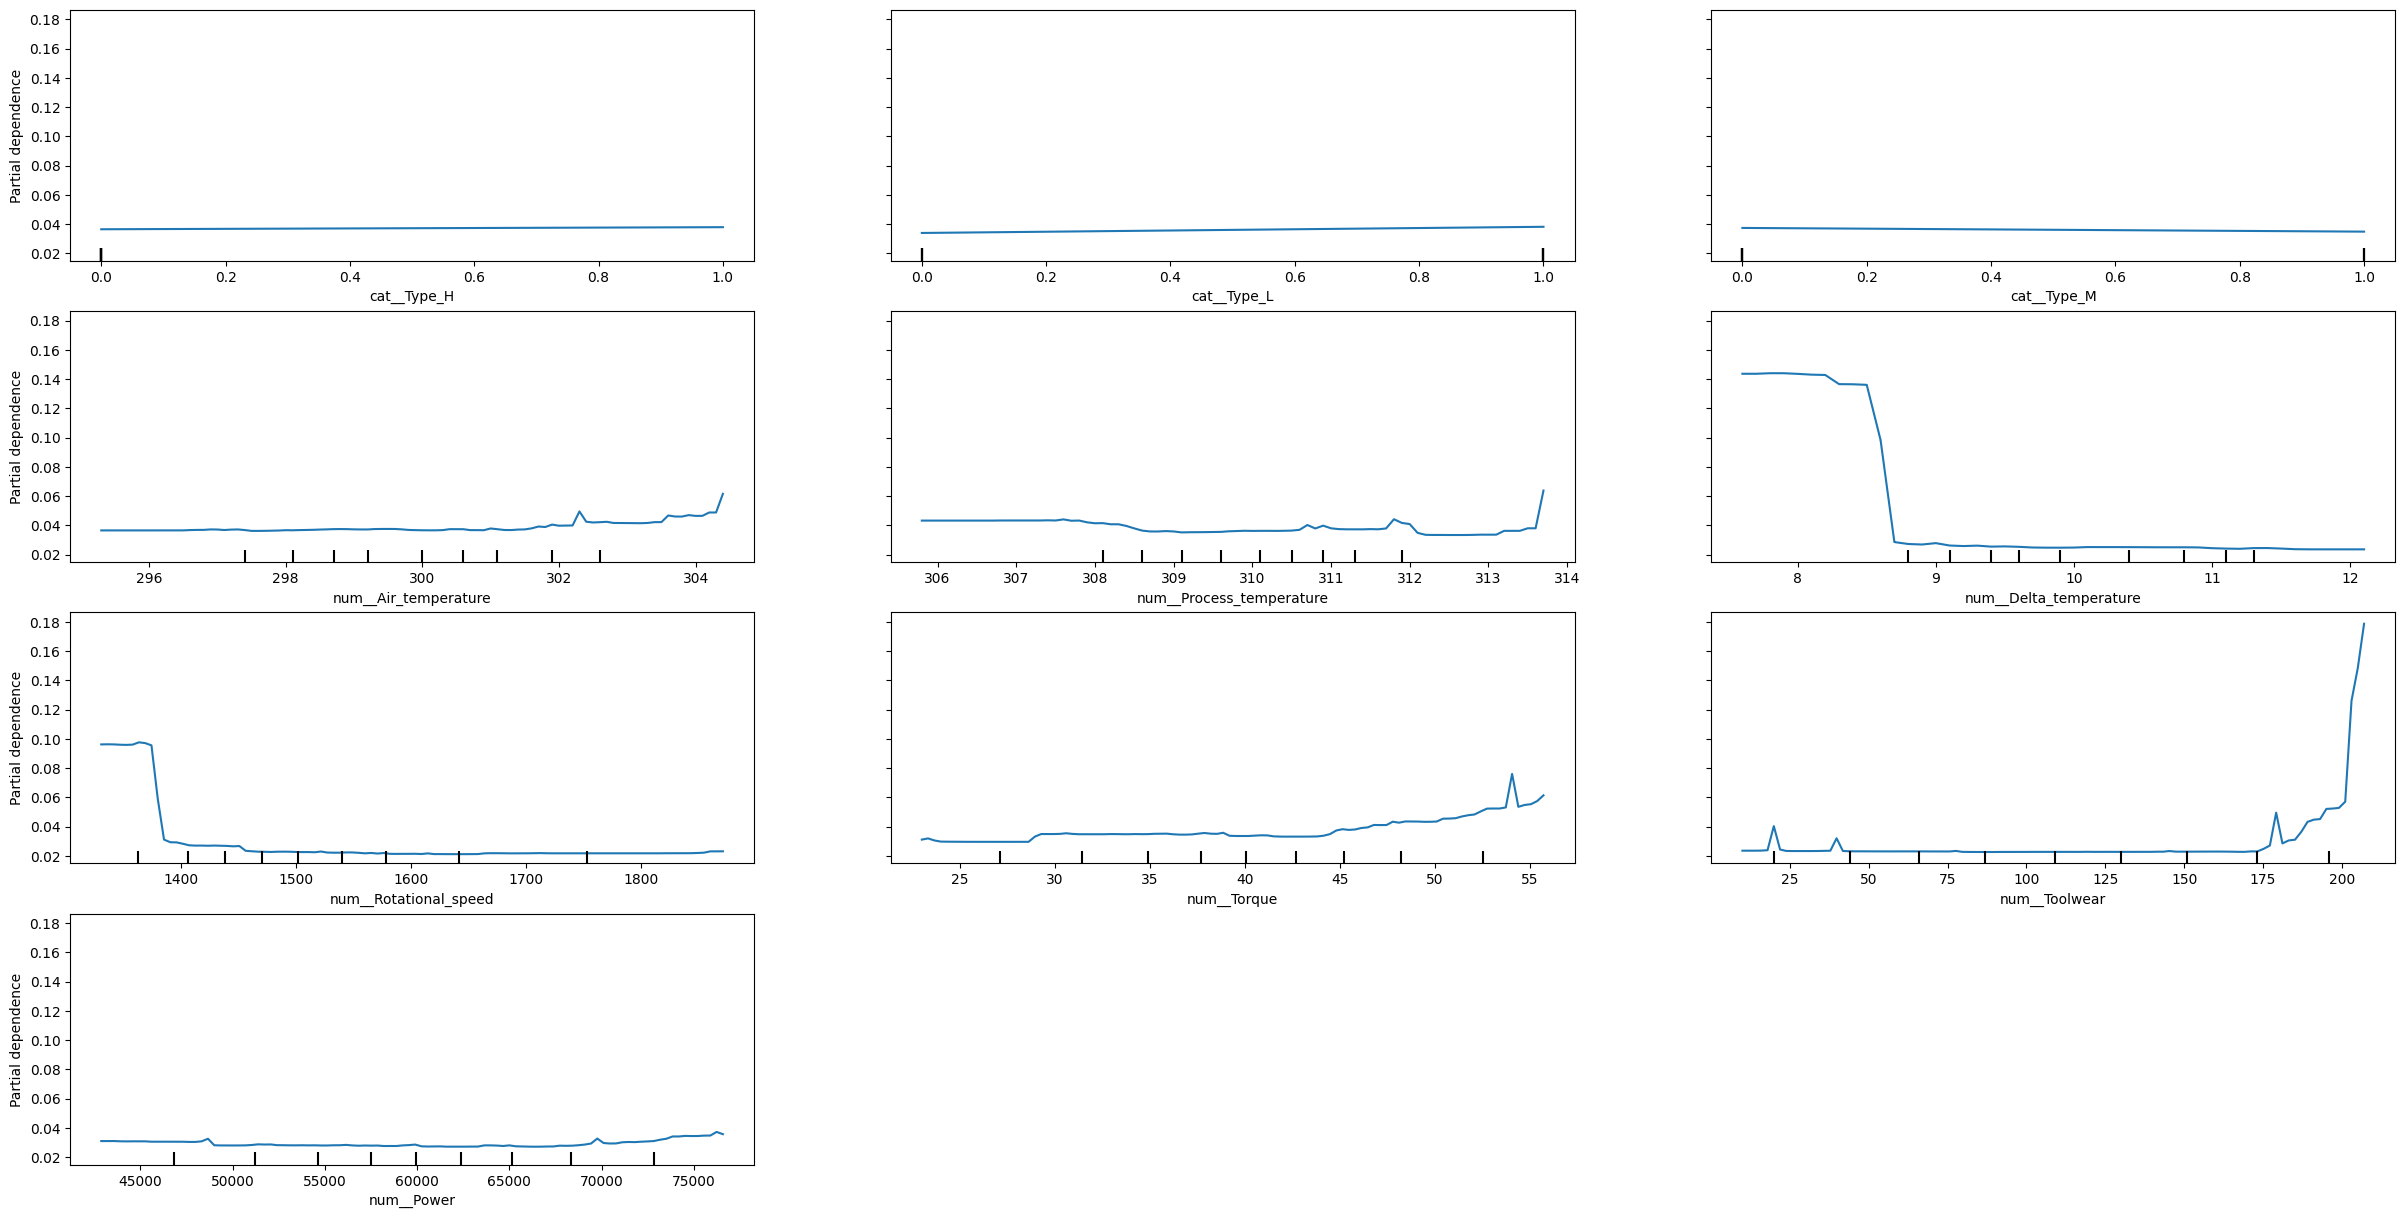

In [51]:
fig, ax = plt.subplots(figsize=(30, 15))  

PartialDependenceDisplay.from_estimator(
    rf_model,
    Xte_trans,
    features = list(Xte_trans.columns) ,
    kind="average",
    ax=ax               
)


In [ ]:
shap.plots.bar(shap_values[..., 1])    